<a href="https://www.kaggle.com/code/atrbyg24/predict-extroverts?scriptVersionId=249315007" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [117]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import optuna

In [118]:
train = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv',index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv',index_col='id')
submission = pd.read_csv("/kaggle/input/playground-series-s5e7/sample_submission.csv")

In [119]:
train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [120]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18524 entries, 0 to 18523
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           17334 non-null  float64
 1   Stage_fear                 16631 non-null  object 
 2   Social_event_attendance    17344 non-null  float64
 3   Going_outside              17058 non-null  float64
 4   Drained_after_socializing  17375 non-null  object 
 5   Friends_circle_size        17470 non-null  float64
 6   Post_frequency             17260 non-null  float64
 7   Personality                18524 non-null  object 
dtypes: float64(5), object(3)
memory usage: 1.3+ MB


In [121]:
train.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,3.137764,5.265106,4.044319,7.996737,4.982097
std,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,3.000000,5.000000,3.000000
50%,2.000000,5.000000,4.000000,8.000000,5.000000
75%,4.000000,8.000000,6.000000,12.000000,7.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [122]:
num_df = train.select_dtypes(include=np.number)
cat_df = train.select_dtypes(include='object')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

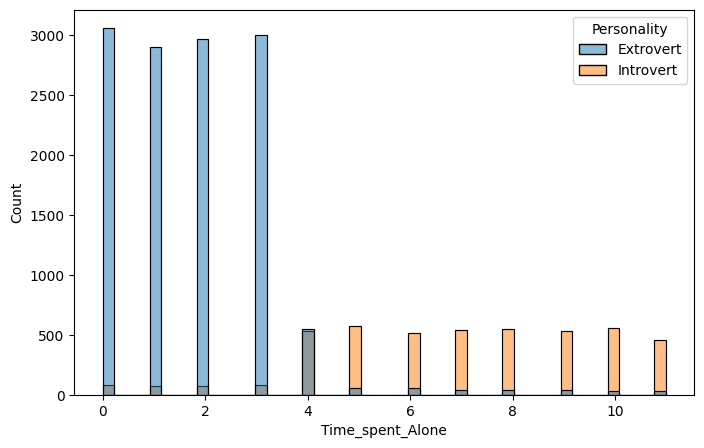

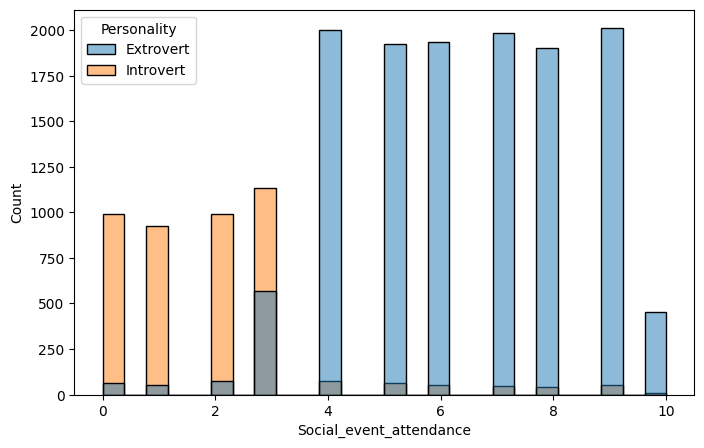

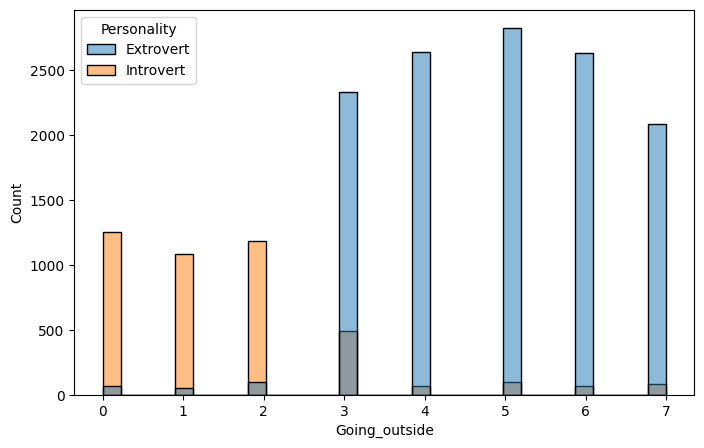

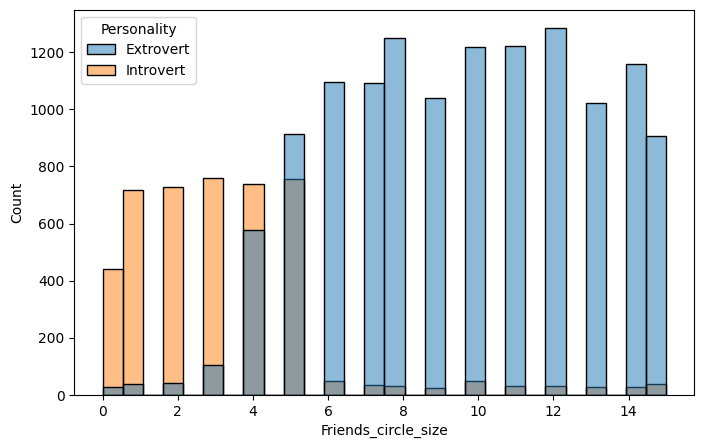

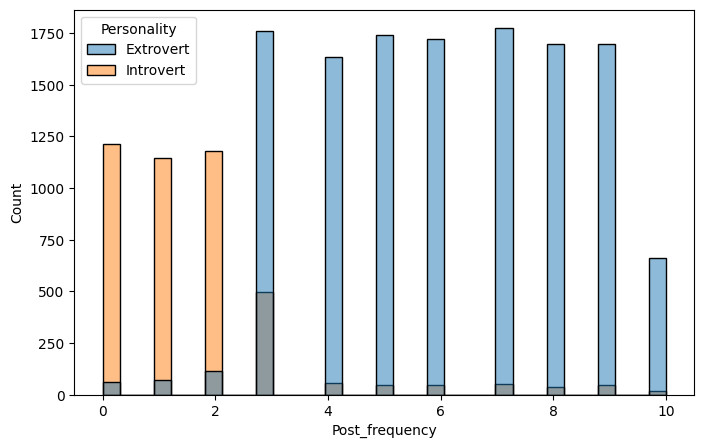

In [123]:
for col in num_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x=col,hue='Personality')

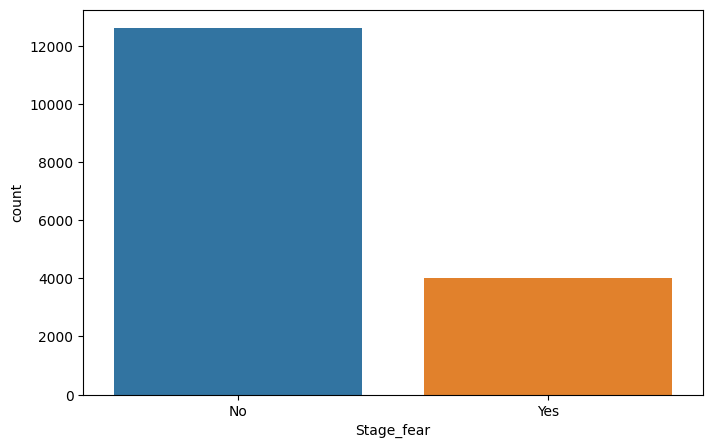

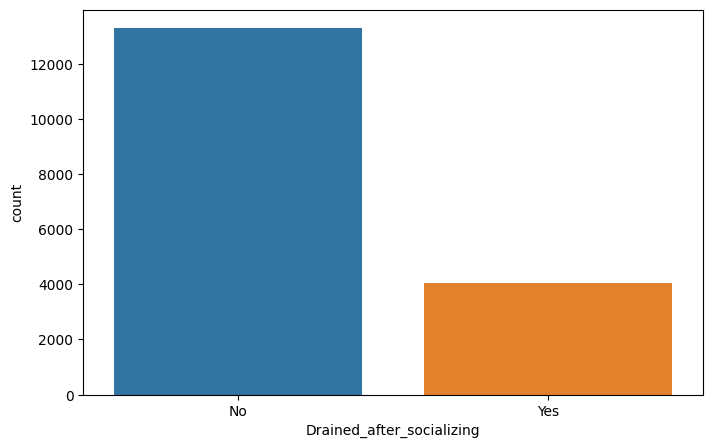

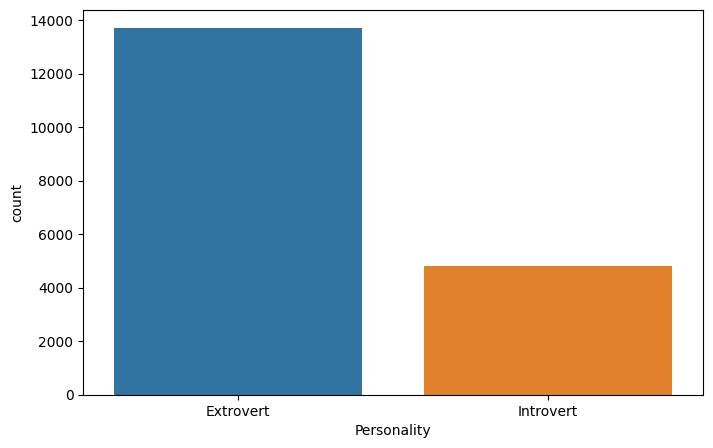

In [124]:
for col in cat_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=cat_df,x=col)

<Axes: >

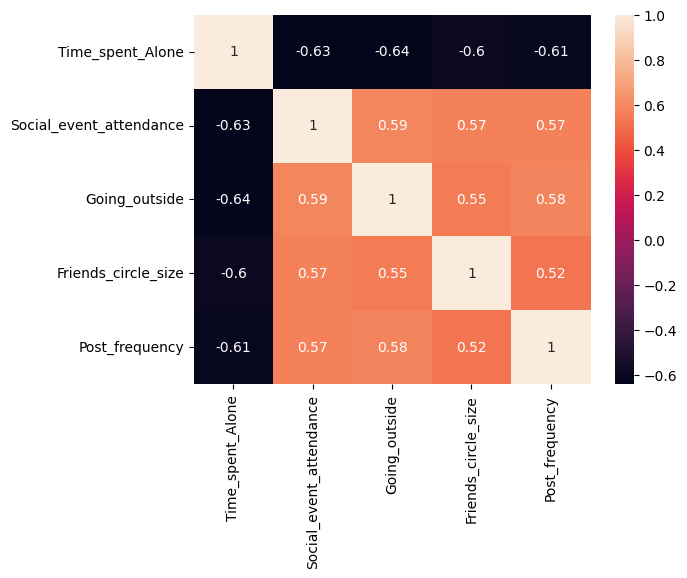

In [125]:
sns.heatmap(num_df.corr(),annot=True)

In [126]:
le = LabelEncoder()
train["Personality_encoded"] = le.fit_transform(train["Personality"])

In [127]:
X = train.drop(columns=["Personality", "Personality_encoded"])
y = train["Personality_encoded"]

In [128]:
combined = pd.concat([X, test], axis=0)
cat_cols = combined.select_dtypes(include="object").columns.tolist()
encoder = OrdinalEncoder()
combined[cat_cols] = encoder.fit_transform(combined[cat_cols])

X = combined.iloc[:len(X)].reset_index(drop=True)
test = combined.iloc[len(X):].reset_index(drop=True)

In [129]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nFull Training set size for Optuna: {len(X_train_full)} samples")
print(f"Held-out Test set size for final evaluation: {len(X_test)} samples")


Full Training set size for Optuna: 14819 samples
Held-out Test set size for final evaluation: 3705 samples


In [130]:
def objective(trial):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters.
    Uses StratifiedKFold for cross-validation.
    """
    
    param = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), 
        "max_depth": trial.suggest_int("max_depth", 3, 9), 
        "eta": trial.suggest_float("eta", 1e-3, 0.3, log=True), 
        "subsample": trial.suggest_float("subsample", 0.6, 1.0), 
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0), 
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10), 
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True), 
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True), 
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "early_stopping_rounds": 50, 
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
        X_train_fold, X_val_fold = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        model = xgb.XGBClassifier(**param, use_label_encoder=False)
        model.fit(X_train_fold, y_train_fold,
                  eval_set=[(X_val_fold, y_val_fold)],
                  verbose=False) 

        y_pred_fold = model.predict(X_val_fold)
        accuracies.append(accuracy_score(y_val_fold, y_pred_fold))


    return np.mean(accuracies)

In [132]:
print("\nStarting Optuna Hyperparameter Optimization...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50) 

print("\nOptuna optimization finished.")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.value:.4f} (Accuracy)")
print("Best hyperparameters found:")
best_params = study.best_trial.params
for key, value in best_params.items():
    print(f"  {key}: {value}")

[I 2025-07-08 00:32:58,556] A new study created in memory with name: no-name-2a55dd35-dba1-48ad-96f6-c001862a0e14



Starting Optuna Hyperparameter Optimization...


[I 2025-07-08 00:33:00,109] Trial 0 finished with value: 0.9684190258350516 and parameters: {'n_estimators': 437, 'max_depth': 9, 'eta': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 2.9152036385288193e-08, 'lambda': 0.08499808989182997, 'alpha': 0.0006440507553993703}. Best is trial 0 with value: 0.9684190258350516.
[I 2025-07-08 00:33:00,755] Trial 1 finished with value: 0.9684190258350517 and parameters: {'n_estimators': 737, 'max_depth': 3, 'eta': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 2.9324868872723725e-07, 'lambda': 2.716051144654844e-06, 'alpha': 0.00015777981883364995}. Best is trial 1 with value: 0.9684190258350517.
[I 2025-07-08 00:33:02,593] Trial 2 finished with value: 0.9684864794453227 and parameters: {'n_estimators': 489, 'max_depth': 5, 'eta': 0.032781876533976156, 'subsample': 0.6557975442608167, 'colsamp


Optuna optimization finished.
Number of finished trials: 50
Best trial: 0.9687 (Accuracy)
Best hyperparameters found:
  n_estimators: 613
  max_depth: 5
  eta: 0.014861185205855205
  subsample: 0.6393423808330961
  colsample_bytree: 0.6957165969518844
  min_child_weight: 2
  gamma: 4.63653404261731e-05
  lambda: 0.0075522219415864265
  alpha: 1.0441352032564197e-08


In [133]:
print("\nTraining final model with best hyperparameters...")
final_xgb_model = xgb.XGBClassifier(**best_params, objective='binary:logistic', eval_metric='logloss',
                                    use_label_encoder=False, random_state=42)
final_xgb_model.fit(X_train_full, y_train_full)


Training final model with best hyperparameters...


XGBClassifier(alpha=1.0441352032564197e-08, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6957165969518844, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.014861185205855205, eval_metric='logloss',
              feature_types=None, gamma=4.63653404261731e-05, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              lambda=0.0075522219415864265, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=613, ...)

In [134]:
print("\nPerforming optimal threshold adjustment on the held-out test set...")

y_test_pred_proba = final_xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.01)
accuracies_test = []
precisions_test = []
recalls_test = []
f1_scores_test = []

for threshold in thresholds:
    y_pred_thresholded = (y_test_pred_proba >= threshold).astype(int)
    accuracies_test.append(accuracy_score(y_test, y_pred_thresholded))
    precisions_test.append(precision_score(y_test, y_pred_thresholded, zero_division=0))
    recalls_test.append(recall_score(y_test, y_pred_thresholded, zero_division=0))
    f1_scores_test.append(f1_score(y_test, y_pred_thresholded, zero_division=0))



Performing optimal threshold adjustment on the held-out test set...


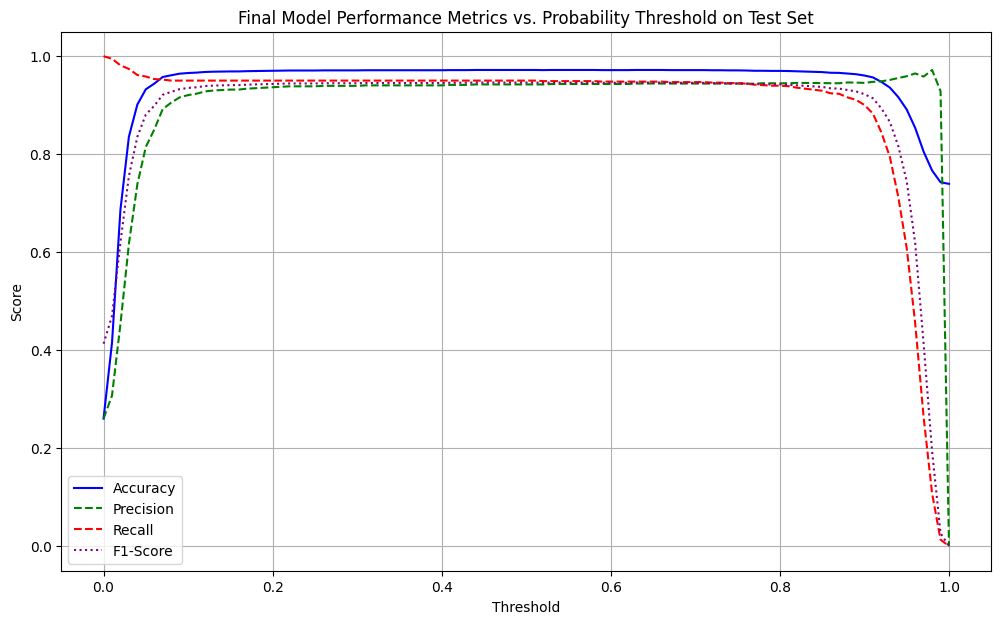

In [135]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, accuracies_test, label='Accuracy', color='blue')
plt.plot(thresholds, precisions_test, label='Precision', color='green', linestyle='--')
plt.plot(thresholds, recalls_test, label='Recall', color='red', linestyle='--')
plt.plot(thresholds, f1_scores_test, label='F1-Score', color='purple', linestyle=':')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Final Model Performance Metrics vs. Probability Threshold on Test Set')
plt.legend()
plt.grid(True)
plt.show()


In [136]:
optimal_threshold_idx_test = np.argmax(accuracies_test)
optimal_threshold_final = thresholds[optimal_threshold_idx_test]
max_accuracy_final = accuracies_test[optimal_threshold_idx_test]

print(f"\nOptimal Threshold for Accuracy on Test Set: {optimal_threshold_final:.2f}")
print(f"Maximum Accuracy achieved on Test Set: {max_accuracy_final:.4f}")

y_test_pred_default = (y_test_pred_proba >= 0.5).astype(int)
default_test_accuracy = accuracy_score(y_test, y_test_pred_default)
print(f"Test Accuracy with default threshold (0.5): {default_test_accuracy:.4f}")

print("\n--- Final Model Predictions with Optimal Threshold ---")
final_predictions = (y_test_pred_proba >= optimal_threshold_final).astype(int)
print("First 10 actual labels:", y_test.head(10).tolist())
print("First 10 optimal predictions:", final_predictions[:10].tolist())



Optimal Threshold for Accuracy on Test Set: 0.44
Maximum Accuracy achieved on Test Set: 0.9719
Test Accuracy with default threshold (0.5): 0.9719

--- Final Model Predictions with Optimal Threshold ---
First 10 actual labels: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
First 10 optimal predictions: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


In [137]:
test_preds = final_xgb_model.predict_proba(test)[:, 1]
final_preds = (test_preds > optimal_threshold_final).astype(int)
submission["Personality"] = le.inverse_transform(final_preds)
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert
